# Part 0: Setup

In [21]:
#Install packages
using Pkg; Pkg.activate("."); Pkg.instantiate();

  Activating project at `~/Desktop/CPC_HGF_tutorial`
    Updating registry at `~/.julia/registries/General.toml`
    Updating `~/Desktop/CPC_HGF_tutorial/Project.toml`
  [320cf53b] + ActionModels v0.7.3
  [336ed68f] + CSV v0.10.17
  [a93c6f00] + DataFrames v1.8.2
  [63d42c3e] + HierarchicalGaussianFiltering v0.7.0
  [f3b207a7] + StatsPlots v0.15.8
    Updating `~/Desktop/CPC_HGF_tutorial/Manifest.toml`
  [47edcb42] + ADTypes v1.24.0
  [621f4979] + AbstractFFTs v1.5.0
  [80f14c24] + AbstractMCMC v5.16.0
⌅ [7a57a42e] + AbstractPPL v0.10.1
  [1520ce14] + AbstractTrees v0.4.5
  [7d9f7c33] + Accessors v0.1.45
  [320cf53b] + ActionModels v0.7.3
  [79e6a3ab] + Adapt v4.7.0
⌅ [0bf59076] + AdvancedHMC v0.7.1
  [5b7e9947] + AdvancedMH v0.8.10
⌅ [576499cb] + AdvancedPS v0.6.2
⌅ [b5ca4192] + AdvancedVI v0.2.12
  [66dad0bd] + AliasTables v1.1.3
  [dce04be8] + ArgCheck v2.5.0
  [7d9fca2a] + Arpack v0.5.4
  [4fba245c] + ArrayInterface v7.30.1
  [4c555306] + ArrayLayouts v1.12.2
  [69666777] + Arrow v

In [ ]:
#Load packages
using HierarchicalGaussianFiltering #For the HGF
using ActionModels                  #For model-fitting and simulation
using StatsPlots                    #For plotting
using DataFrames, CSV, Downloads    #For loading data

# Part 1: Belief Updates with the HGF

In this first section, we will try using the HGF for a classic example dataset: the exchange rate between the Swiss Franc and the US Dollar.

In [4]:
# Read into a DataFrame
timeseries = CSV.read(CSV.download(
  "https://raw.githubusercontent.com/ComputationalPsychiatry/HierarchicalGaussianFiltering.jl/uHGF_real/docs/julia_files/tutorials/data/classic_usdchf_inputs.csv"
  ), DataFrame).inputs

614-element Vector{Float64}:
 1.0357
 1.0319
 1.0359
 1.0343
 1.0303
 1.0328
 1.0311
 1.0326
 1.0247
 1.0245
 ⋮
 0.8135
 0.8183
 0.8121
 0.8014
 0.7885
 0.7889
 0.7889
 0.7876
 0.8241

In [5]:
#Create premade HGF
hgf = premade_hgf("continuous_2level")

-- HGF struct --
Number of input nodes: 1
(1 continuous, 0 binary and 0 categorical)
Number of state nodes: 2
(2 continuous, 0 binary, and 0 categorical)


Here is a depiction of the generative model of the continuous 2level HGF

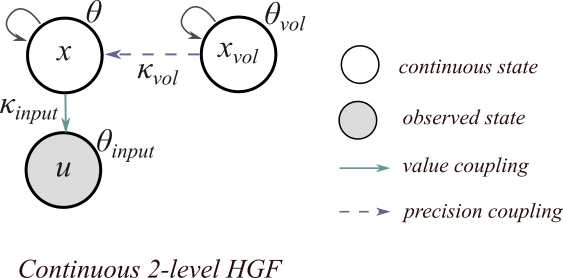

In [6]:
#Set parameters
parameters = Dict(
  ("x", "volatility") => -13,                  #ω₁
  ("x", "drift") => 0,                         #ρ₁
  ("x", "autoconnection_strength") => 1,       #λ₁
  ("x", "initial_mean") => 1.0,                #μ₀
  ("x", "initial_precision") => 1000,          #π₀

  ("xvol", "volatility") => -2,                #ω₂
  ("xvol", "drift") => 0,                      #ρ₂
  ("xvol", "autoconnection_strength") => 1,    #λ₂
  ("xvol", "initial_mean") => 1.0,             #μ₀
  ("xvol", "initial_precision") => 10,         #π₀

  ("u", "input_noise") => -9,                  #ωᵤ

  ("x", "xvol", "coupling_strength") => 1.     #κ₂₁
)

set_parameters!(hgf, parameters)

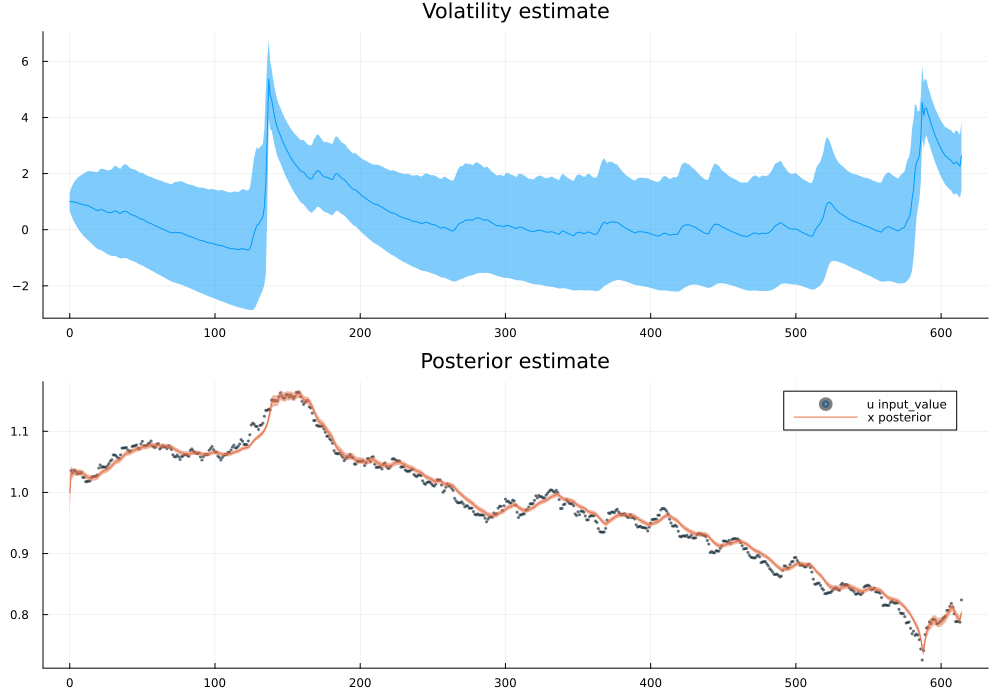

In [7]:
#Give observations to the HGF
reset!(hgf)
multiple_inputs!(hgf, timeseries)

#Plot the inferred state
plt_x = plot(hgf, "u", markersize = 1, alpha =0.5)
plot!(hgf, "x")
title!("Posterior estimate")

#Plot the inferred volatility
plt_vol = plot(hgf, "xvol")
title!("Volatility estimate", legend = false)

#Plot together
plot(
  plt_vol,
  plt_x,
  layout = (2,1),
  size = (1000,700)
)

## Exercise 1
The different parameters of the HGF affect its belief updates in different ways.
Vary the parameters above, and figure out how.
The most commonly used parameter is the volatility, omega, which controls the learning rate.
Note that with some parameter settings, particularly when omega is too high, the HGF may return an error.

# Part 2: Using Custom HGFs
In this section, we will create custom HGF structures and fit them to the data above.
In the following are four examples:
A simple HGF, which is a Kalman filter, where an observation has a single cause.
A continuos 2level HGF, where the cause has a volatility parent.
A noise learning HGF, where the observation node also has a noise parent.
A drift learning HGF, where the state node x has a drift parent.

In [8]:
#Create a simple HGF

#List of nodes
nodes = [
    ContinuousInput(name = "u"),
    ContinuousState(name = "x"),
    ]

#List of child-parent relations
edges = Dict(
    ("u", "x") => ObservationCoupling(),
)

#Initialize the HGF
hgf_simple = init_hgf(
    nodes = nodes,
    edges = edges,
)

┌ Warning: No update order specified. Using the order in which nodes were inputted
└ @ HierarchicalGaussianFiltering /Users/peter/.julia/packages/HierarchicalGaussianFiltering/NMcA2/src/create_hgf/init_hgf.jl:78


-- HGF struct --
Number of input nodes: 1
(1 continuous, 0 binary and 0 categorical)
Number of state nodes: 1
(1 continuous, 0 binary, and 0 categorical)


In [9]:
#Create a 2-level continuous HGF

#List of nodes
nodes = [
    ContinuousInput(name = "u"),
    ContinuousState(name = "x"),
    ContinuousState(name = "xvol"),
    ]

#List of child-parent relations
edges = Dict(
    ("u", "x") => ObservationCoupling(),
    ("x", "xvol") => VolatilityCoupling(),
)

#Initialize the HGF
hgf_continuous_2level = init_hgf(
    nodes = nodes,
    edges = edges,
)

┌ Warning: No update order specified. Using the order in which nodes were inputted
└ @ HierarchicalGaussianFiltering /Users/peter/.julia/packages/HierarchicalGaussianFiltering/NMcA2/src/create_hgf/init_hgf.jl:78


-- HGF struct --
Number of input nodes: 1
(1 continuous, 0 binary and 0 categorical)
Number of state nodes: 2
(2 continuous, 0 binary, and 0 categorical)


In [10]:
#Create a noise-learning continuous HGF

#List of nodes
nodes = [
    ContinuousInput(name = "u"),
    ContinuousState(name = "xnoise"),
    ContinuousState(name = "x"),
    ContinuousState(name = "xvol"),
    ]

#List of child-parent relations
edges = Dict(
    ("u", "x") => ObservationCoupling(),
    ("u", "xnoise") => NoiseCoupling(),
    ("x", "xvol") => VolatilityCoupling(),
)

#Initialize the HGF
hgf_noiselearn = init_hgf(
    nodes = nodes,
    edges = edges,
)

┌ Warning: No update order specified. Using the order in which nodes were inputted
└ @ HierarchicalGaussianFiltering /Users/peter/.julia/packages/HierarchicalGaussianFiltering/NMcA2/src/create_hgf/init_hgf.jl:78


-- HGF struct --
Number of input nodes: 1
(1 continuous, 0 binary and 0 categorical)
Number of state nodes: 3
(3 continuous, 0 binary, and 0 categorical)


In [11]:
#Create a drift-learning continuous HGF

#List of nodes
nodes = [
    ContinuousInput(name = "u"),
    ContinuousState(name = "x"),
    ContinuousState(name = "xdrift"),
    ContinuousState(name = "xvol"),
    ]

#List of child-parent relations
edges = Dict(
    ("u", "x") => ObservationCoupling(),
    ("x", "xdrift") => DriftCoupling(),
    ("x", "xvol") => VolatilityCoupling(),
)

#Initialize the HGF
hgf_noiselearn = init_hgf(
    nodes = nodes,
    edges = edges,
)

┌ Warning: No update order specified. Using the order in which nodes were inputted
└ @ HierarchicalGaussianFiltering /Users/peter/.julia/packages/HierarchicalGaussianFiltering/NMcA2/src/create_hgf/init_hgf.jl:78


-- HGF struct --
Number of input nodes: 1
(1 continuous, 0 binary and 0 categorical)
Number of state nodes: 3
(3 continuous, 0 binary, and 0 categorical)


Depending on the network, the parameters and belief states will vary:

In [12]:
#Use this to get an overview of the different parameters in the model
parameters = get_parameters(hgf_noiselearn)

for (key, value) in pairs(parameters)
  println("$key : $value")
end

x_drift : 0
xdrift_volatility : -2
x_initial_precision : 1
xvol_autoconnection_strength : 1
xvol_initial_mean : 0
xdrift_initial_precision : 1
u_input_noise : -2
x_volatility : -2
x_xdrift_coupling_strength : 1
x_initial_mean : 0
u_bias : 0
xdrift_autoconnection_strength : 1
xvol_volatility : -2
x_xvol_coupling_strength : 1
xvol_drift : 0
xdrift_drift : 0
xvol_initial_precision : 1
xdrift_initial_mean : 0
x_autoconnection_strength : 1


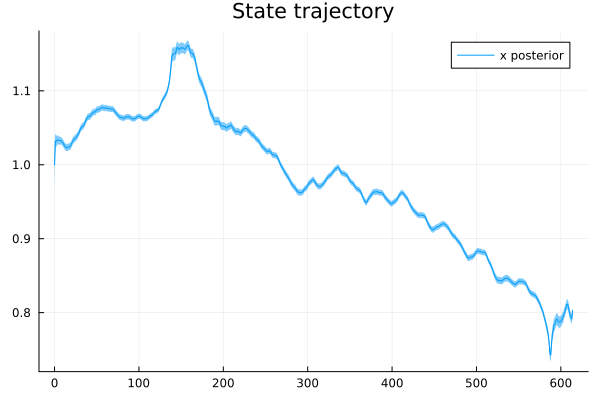

In [15]:
#It is possible to plot different belief states for the HGF
plot(hgf, ("x", "prediction_mean"))

#Possible belief states:
# posterior_mean
# posterior_precision
# prediction_mean
# prediction_precision
# value_prediction_error
# volatility_prediction_error

Here is a table showing all the parameters and belief states in the HGF

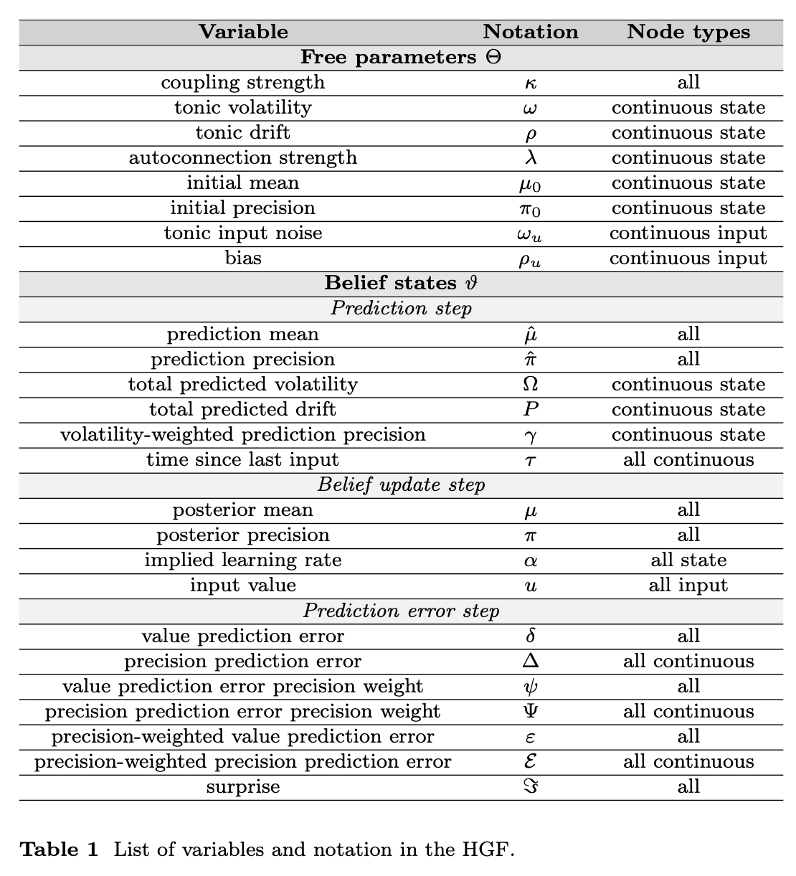

## Exercise 2
Try using the different HGF types to filter the data.
Change their parameter values.
Plot their different belief states.
See if you can find differences between the models, and get a sense of how the HGF network affects belief updates.
Remember to reset the HGF before giving it new inputs.

## Exercise 3
Try building your own HGF network. Children can have multiple parents. Parents can have multiple children. Set parameters, give it the data, and plot as above.
Remember to reset the HGF before giving it new inputs.

# Part 3 (Optional): Filtering the World's Weather
In this next section, we will try out the HGF for some real-world data: the weather.

We will use data made available [here](https://www.renewables.ninja/). This database contains hourly recordings of various weather parameters that have been tracked over one year at different positions in the world. We will try giving this to the HGF to filter.

The data from Aarhus can be loaded using the following function call:

In [17]:
#Load data about the weather in Aarhus
aarhus_weather_df = CSV.read(
  CSV.download("https://raw.githubusercontent.com/ilabcode/hgf-data/main/datasets/weather.csv"),
   DataFrame)

Row,time,t2m,prectotland,precsnoland,snomas,rhoa,swgdn,swtdn,cldtot
,String31,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,2019-01-01 00:00,7.387,0.124,0.0,0.0,1.249,0.0,0.0,0.931
2,2019-01-01 01:00,7.472,0.2,0.0,0.0,1.247,0.0,0.0,0.865
3,2019-01-01 02:00,7.635,0.196,0.0,0.0,1.244,0.0,0.0,0.701
4,2019-01-01 03:00,7.224,0.061,0.0,0.0,1.245,0.0,0.0,0.387
5,2019-01-01 04:00,6.147,0.018,0.0,0.0,1.25,0.0,0.0,0.128
6,2019-01-01 05:00,5.573,0.022,0.0,0.0,1.253,0.0,0.0,0.137
7,2019-01-01 06:00,5.521,0.022,0.0,0.0,1.253,0.0,0.0,0.329
8,2019-01-01 07:00,5.587,0.022,0.0,0.0,1.252,0.047,0.358,0.359
9,2019-01-01 08:00,5.754,0.02,0.0,0.0,1.251,16.719,74.416,0.287


In [18]:
#Extract an example data series
timeseries = aarhus_weather_df[1:720, "t2m"]

720-element Vector{Float64}:
 7.387
 7.472
 7.635
 7.224
 6.147
 5.573
 5.521
 5.587
 5.754
 5.792
 ⋮
 1.083
 0.965
 0.874
 0.81
 0.763
 0.728
 0.691
 0.634
 0.626

## Exercise 4

Try filtering this data with the HGF.
Select a city and download a recording, or use the data frame loaded above.
Create a network and let it observe the data. Find a network and parameter values that lets it follow the data well - if possible!
You can also experiment with multiple input nodes and multiple inputs, etc.



# Part 4 (Optional): Filtering the Predictive Inference Task

As the final filtering exercise, we will use the input data from [this experiment](https://www.nature.com/articles/s41467-023-39823-5), called the predictive inference or Jumping Gaussian Estimation Task.
Here, participants are presented with continuous inputs representing different points one circle, and have to predict where a cannonball is going to land.
The place where the cannonball lands is sampled from a Gaussian distribution.
This Gaussian changes in two ways: in some periods, the level of noise is high or low, and the position of the Gaussian jumps between different places.

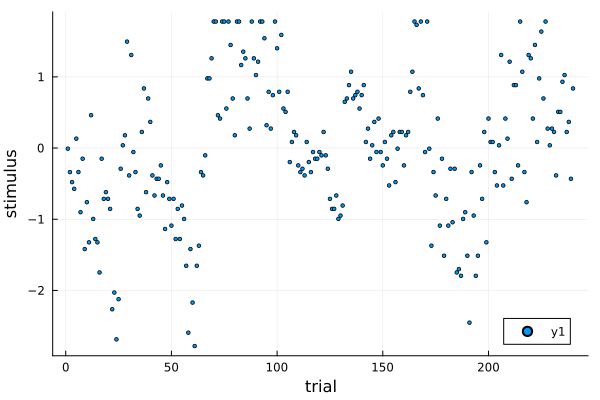

In [20]:
#Read into a DataFrame
data = CSV.read(CSV.download(
  "https://raw.githubusercontent.com/ComputationalPsychiatry/HierarchicalGaussianFiltering.jl/main/docs/julia_files/tutorials/data/classic_cannonball_data.csv"
  ), DataFrame, missingstring = ["NaN", ""])

#Filter the data for the first session for the first participant
data = filter(:ID => ==(20), data)
data = filter(:session => ==(1), data)

#z-score the outcome
z_μ = mean(data.outcome)
z_σ = std(data.outcome)
data.outcome_z = (data.outcome .- z_μ) ./ z_σ

#Extract data
timeseries = data.outcome_z

plot(timeseries, seriestype = :scatter, markersize = 2, xlabel = "trial", ylabel = "stimulus")

## Exercise 5
Create an HGF and find parameters that can describe the data well.
It is probably useful to include noise learning. There are plenty of ways to extend the model, with drift and volatility learning.
Consider what kinds of models might be cognitively realistic, and which not.